<style>
/* Paper-style layout for both Jupyter and nbconvert HTML. */
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# Continuous Time Processes: Brownian Motion, Martingales, and Path Roughness


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
GOLD = "#B79A20"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def simulate_brownian_paths(n_paths, n_steps, T, rng):
    dt = T / n_steps
    increments = np.sqrt(dt) * rng.standard_normal((n_paths, n_steps))
    paths = np.column_stack((np.zeros(n_paths), np.cumsum(increments, axis=1)))
    time = np.linspace(0.0, T, n_steps + 1)
    return time, paths, increments


def standard_normal_density(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

## 1. Brownian motion at a glance

A standard Brownian motion $(B_t)_{t\in[0,1]}$ starts from $B_0=0$, has independent increments on disjoint time intervals, satisfies

$$
B_t-B_s\sim N(0,t-s),\qquad 0\leq s\leq t\leq1,
$$

and has almost surely continuous paths. The four panels below isolate the observable signature of each property.

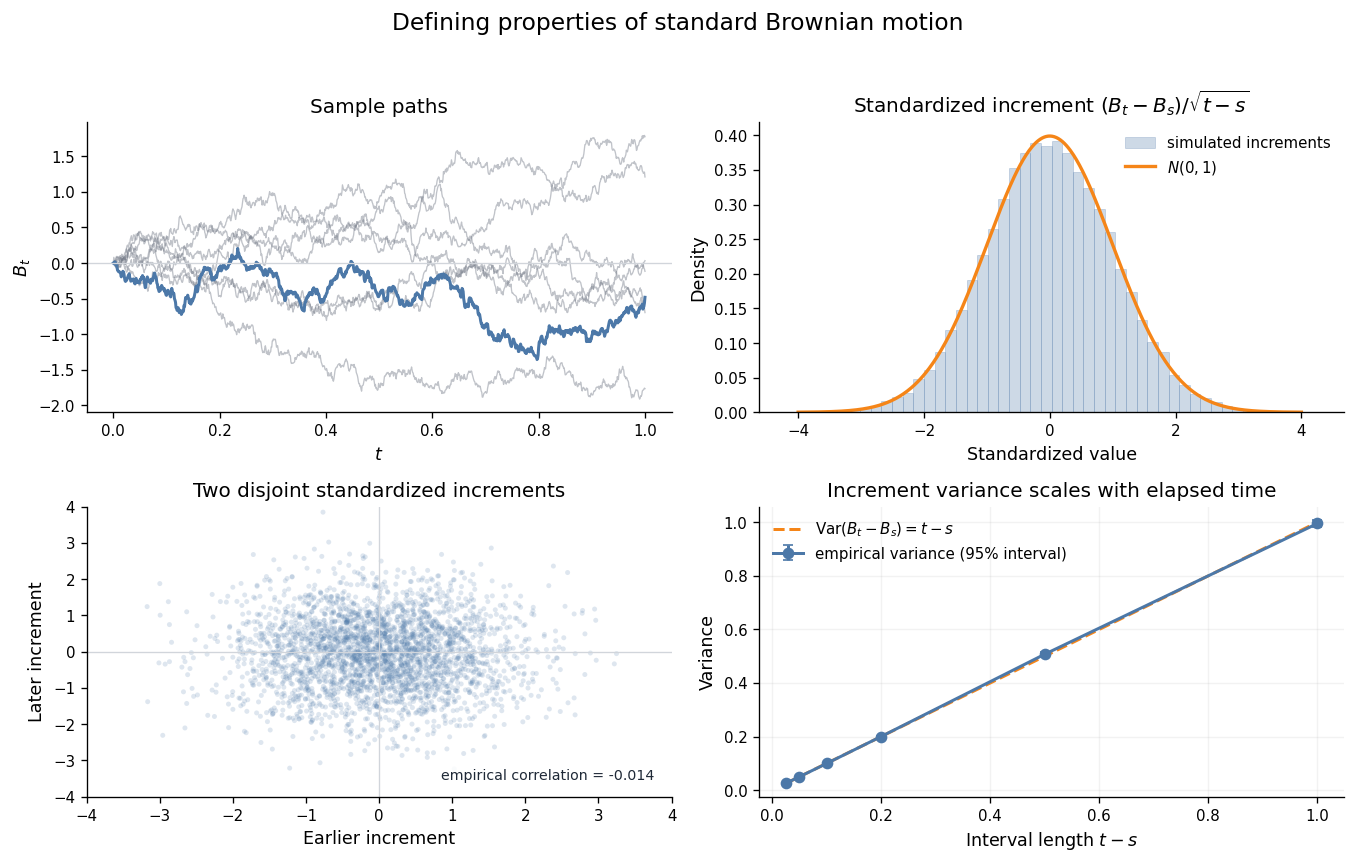

In [2]:
rng = np.random.default_rng(SEED + 1)

# Continuous paths starting at zero.
time, sample_paths, _ = simulate_brownian_paths(n_paths=8, n_steps=1000, T=1.0, rng=rng)

# Gaussian scaling for an increment of length delta_t.
delta_t = 0.20
n_samples = 40_000
standardized_increments = (
    np.sqrt(delta_t) * rng.standard_normal(n_samples)
) / np.sqrt(delta_t)

# Two disjoint standardized increments.
n_scatter = 3_000
z_left = rng.standard_normal(n_scatter)
z_right = rng.standard_normal(n_scatter)
empirical_correlation = np.corrcoef(z_left, z_right)[0, 1]

# Variance as a function of interval length.
interval_lengths = np.array([0.025, 0.05, 0.10, 0.20, 0.50, 1.00])
variance_samples = np.vstack([
    np.sqrt(length) * rng.standard_normal(n_samples)
    for length in interval_lengths
])
empirical_variances = variance_samples.var(axis=1, ddof=1)
variance_se = empirical_variances * np.sqrt(2 / (n_samples - 1))

fig, axes = plt.subplots(2, 2, figsize=(11.4, 7.3))

for path in sample_paths[:-1]:
    axes[0, 0].plot(time, path, color=GREY, linewidth=0.8, alpha=0.42)
axes[0, 0].plot(time, sample_paths[-1], color=BLUE, linewidth=1.8)
axes[0, 0].axhline(0, color=LIGHT_GREY, linewidth=0.8)
axes[0, 0].set_title("Sample paths")
axes[0, 0].set_xlabel("$t$")
axes[0, 0].set_ylabel("$B_t$")

x_density = np.linspace(-4, 4, 500)
axes[0, 1].hist(
    standardized_increments,
    bins=50,
    density=True,
    color=BLUE,
    alpha=0.28,
    edgecolor=BLUE,
    linewidth=0.5,
    label="simulated increments",
)
axes[0, 1].plot(x_density, standard_normal_density(x_density), color=ORANGE, linewidth=2, label=r"$N(0,1)$")
axes[0, 1].set_title(r"Standardized increment $(B_t-B_s)/\sqrt{t-s}$")
axes[0, 1].set_xlabel("Standardized value")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend(frameon=False)

axes[1, 0].scatter(z_left, z_right, s=9, color=BLUE, alpha=0.18, edgecolors="none")
axes[1, 0].axhline(0, color=LIGHT_GREY, linewidth=0.8)
axes[1, 0].axvline(0, color=LIGHT_GREY, linewidth=0.8)
axes[1, 0].set_xlim(-4, 4)
axes[1, 0].set_ylim(-4, 4)
axes[1, 0].set_title("Two disjoint standardized increments")
axes[1, 0].set_xlabel("Earlier increment")
axes[1, 0].set_ylabel("Later increment")
axes[1, 0].text(
    0.97,
    0.05,
    f"empirical correlation = {empirical_correlation:+.3f}",
    transform=axes[1, 0].transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    color=INK,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 2},
)

axes[1, 1].errorbar(
    interval_lengths,
    empirical_variances,
    yerr=1.96 * variance_se,
    color=BLUE,
    marker="o",
    linewidth=1.8,
    capsize=3,
    label="empirical variance (95% interval)",
)
axes[1, 1].plot(interval_lengths, interval_lengths, color=ORANGE, linestyle="--", linewidth=1.8, label=r"$\operatorname{Var}(B_t-B_s)=t-s$")
axes[1, 1].set_title("Increment variance scales with elapsed time")
axes[1, 1].set_xlabel("Interval length $t-s$")
axes[1, 1].set_ylabel("Variance")
axes[1, 1].legend(frameon=False)
axes[1, 1].grid(alpha=0.16)

fig.suptitle("Defining properties of standard Brownian motion", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> Fine-grid renderings of Brownian paths, Gaussian increments, disjoint-increment dependence, and variance scaling.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The path panel joins fine-grid Brownian values by straight segments; Definition 3.2 supplies the almost-sure continuity statement for Brownian motion itself. Standardizing an increment by $\sqrt{t-s}$ produces the standard normal shape. The two disjoint increments are jointly Gaussian, so zero covariance implies their independence; the nearly circular cloud and near-zero sample correlation are finite-sample illustrations. The variance estimates similarly follow the reference relation $\operatorname{Var}(B_t-B_s)=t-s$ within the displayed simulation intervals.</p>

## 2. From the Haar basis to Brownian motion

Chapter 2 introduced the Haar basis $(H_n)_{n\in\mathbb N}$. If $(Z_n)_{n\in\mathbb N}$ are independent with $Z_n\sim N(0,1)$, Chapter 3 constructs Brownian motion from

$$
X_t=\sum_{n=0}^{\infty}\left\langle H_n,1_{[0,t]}\right\rangle Z_n.
$$

The same Gaussian coefficients are carried from one level to the next, producing successive refinements of a single path. In the right panel,

$$
\left\|X^{(L)}-X^{(L-1)}\right\|_\infty
=\max_{0\leq t\leq1}\left|X_t^{(L)}-X_t^{(L-1)}\right|
$$

is the largest vertical change anywhere on $[0,1]$ caused by adding level $L$.


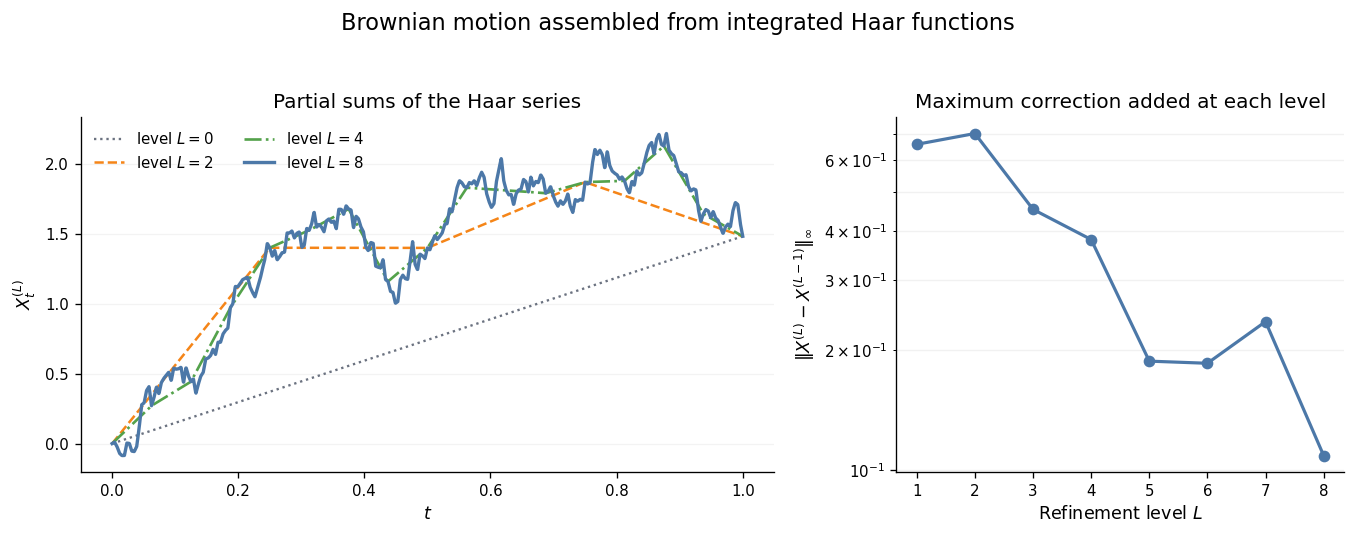

In [3]:
def integrated_haar(index, points):
    if index == 0:
        return points.copy()

    scale = int(np.floor(np.log2(index)))
    shift = index - 2**scale
    left = shift / 2**scale
    middle = (shift + 0.5) / 2**scale
    right = (shift + 1.0) / 2**scale
    amplitude = 2 ** (scale / 2)

    values = np.zeros_like(points)
    rising = (points >= left) & (points < middle)
    falling = (points >= middle) & (points < right)
    values[rising] = amplitude * (points[rising] - left)
    values[falling] = amplitude * (right - points[falling])
    return values


rng = np.random.default_rng(SEED + 2)
time = np.linspace(0.0, 1.0, 2001)
max_level = 8
gaussian_coefficients = rng.standard_normal(2**max_level)

series_terms = np.asarray([
    gaussian_coefficients[index] * integrated_haar(index, time)
    for index in range(2**max_level)
])

approximations = {
    level: series_terms[: 2**level].sum(axis=0)
    for level in range(max_level + 1)
}
correction_levels = np.arange(1, max_level + 1)
correction_norms = np.asarray([
    np.max(np.abs(approximations[level] - approximations[level - 1]))
    for level in correction_levels
])

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5), gridspec_kw={"width_ratios": [1.55, 1]})

shown_levels = [0, 2, 4, 8]
styles = [
    (GREY, ":", 1.4),
    (ORANGE, "--", 1.5),
    (GREEN, "-.", 1.6),
    (BLUE, "-", 2.0),
]
for level, (color, linestyle, linewidth) in zip(shown_levels, styles):
    axes[0].plot(
        time,
        approximations[level],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        label=rf"level $L={level}$",
    )
axes[0].set_title("Partial sums of the Haar series")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$X_t^{(L)}$")
axes[0].legend(frameon=False, ncol=2)
axes[0].grid(axis="y", alpha=0.15)

axes[1].plot(correction_levels, correction_norms, color=BLUE, marker="o", linewidth=1.9)
axes[1].set_yscale("log")
axes[1].set_xticks(correction_levels)
axes[1].set_title("Maximum correction added at each level")
axes[1].set_xlabel("Refinement level $L$")
axes[1].set_ylabel(r"$\|X^{(L)}-X^{(L-1)}\|_\infty$")
axes[1].grid(axis="y", which="both", alpha=0.17)

fig.suptitle("Brownian motion assembled from integrated Haar functions", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


<p class="figure-caption"><strong>Figure 2.</strong> Partial sums of the Haar-series construction and the maximum correction contributed by each new level.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The four curves on the left are successive versions of the same simulated path: level $0$ supplies the broad linear component, and levels $2$, $4$, and $8$ retain all earlier terms while adding increasingly local triangular corrections. In the right panel, the point at level $L$ is the largest vertical distance anywhere between $X^{(L)}$ and $X^{(L-1)}$. For example, the value near $0.11$ at $L=8$ means that adding level $8$ moves the level-$7$ path by at most about $0.11$ on the displayed grid. New Gaussian coefficients can make one correction slightly larger than the previous one; across levels, the corrections become increasingly local and generally smaller, allowing the partial sums to settle into a continuous but irregular path.</p>

## 3. Brownian filtration and continuous martingales

The standard augmented Brownian filtration $(\mathcal F_t)_{t\geq0}$ is the right-continuous completion of the natural filtration: it records the path observed up to time $t$ and includes the relevant null events. A process with $M_t\in L^2(\Omega,\mathcal F_t,P)$ for every $t$ is a martingale when

$$
\mathbb E(M_t\mid\mathcal F_s)=M_s,\qquad 0\leq s\leq t.
$$

It is a continuous martingale when its paths are continuous almost surely. Brownian motion $(B_t)$ is the basic example. The compensated square $(B_t^2-t)$ is another martingale used later in the hitting-time calculation.

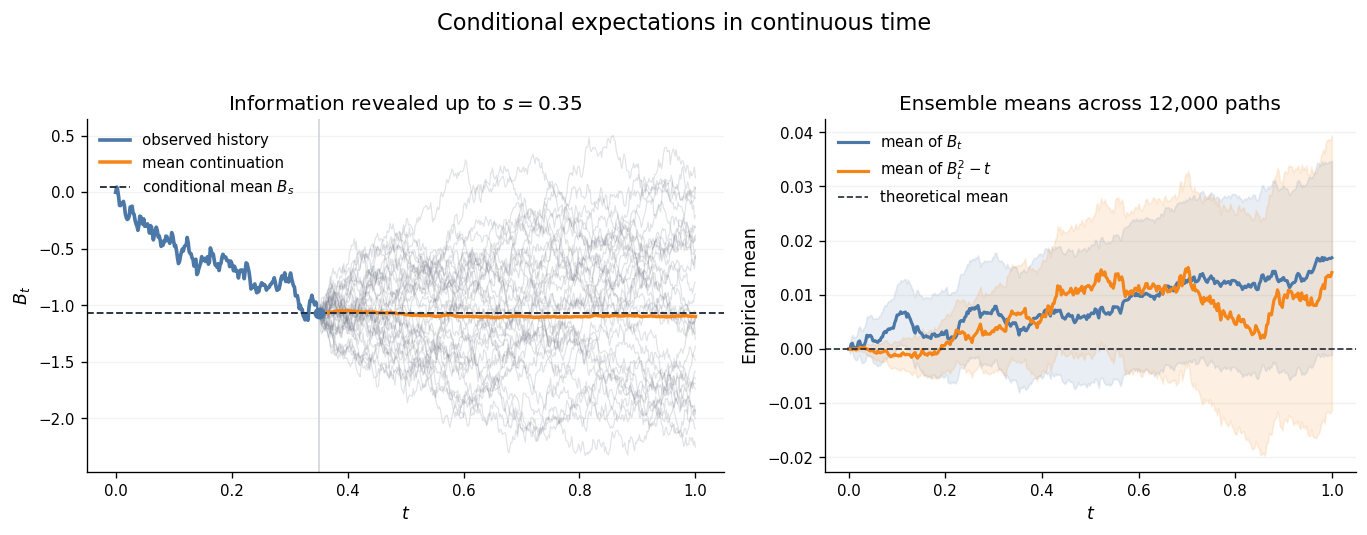

In [4]:
rng = np.random.default_rng(SEED + 3)
T = 1.0
n_steps = 600
time = np.linspace(0.0, T, n_steps + 1)
dt = T / n_steps
conditioning_time = 0.35
conditioning_index = int(round(conditioning_time / dt))

# One observed history and many conditionally independent continuations.
observed_increments = np.sqrt(dt) * rng.standard_normal(conditioning_index)
observed_path = np.concatenate(([0.0], np.cumsum(observed_increments)))
value_at_s = observed_path[-1]

n_continuations = 400
future_steps = n_steps - conditioning_index
future_increments = np.sqrt(dt) * rng.standard_normal((n_continuations, future_steps))
future_paths = np.column_stack((
    np.full(n_continuations, value_at_s),
    value_at_s + np.cumsum(future_increments, axis=1),
))
future_time = time[conditioning_index:]
conditional_mean = future_paths.mean(axis=0)

# Across-path checks for B_t and B_t^2 - t.
n_paths = 12_000
check_time, brownian_paths, _ = simulate_brownian_paths(
    n_paths=n_paths,
    n_steps=400,
    T=T,
    rng=np.random.default_rng(SEED + 303),
)
mean_brownian = brownian_paths.mean(axis=0)
mean_compensated_square = (brownian_paths**2 - check_time).mean(axis=0)
se_brownian = np.sqrt(check_time / n_paths)
se_compensated_square = np.sqrt(2) * check_time / np.sqrt(n_paths)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), gridspec_kw={"width_ratios": [1.2, 1]})

axes[0].plot(time[: conditioning_index + 1], observed_path, color=BLUE, linewidth=2.2, label="observed history")
for path in future_paths[:35]:
    axes[0].plot(future_time, path, color=GREY, linewidth=0.7, alpha=0.20)
axes[0].plot(future_time, conditional_mean, color=ORANGE, linewidth=2.1, label="mean continuation")
axes[0].axhline(value_at_s, color=INK, linestyle="--", linewidth=1.1, label=r"conditional mean $B_s$")
axes[0].axvline(conditioning_time, color=LIGHT_GREY, linewidth=1.0)
axes[0].scatter([conditioning_time], [value_at_s], color=BLUE, s=38, zorder=4)
axes[0].set_title(rf"Information revealed up to $s={conditioning_time:.2f}$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$B_t$")
axes[0].legend(frameon=False, loc="upper left")
axes[0].grid(axis="y", alpha=0.14)

axes[1].fill_between(check_time, mean_brownian - 1.96 * se_brownian, mean_brownian + 1.96 * se_brownian, color=BLUE, alpha=0.12)
axes[1].fill_between(
    check_time,
    mean_compensated_square - 1.96 * se_compensated_square,
    mean_compensated_square + 1.96 * se_compensated_square,
    color=ORANGE,
    alpha=0.12,
)
axes[1].plot(check_time, mean_brownian, color=BLUE, linewidth=1.9, label=r"mean of $B_t$")
axes[1].plot(check_time, mean_compensated_square, color=ORANGE, linewidth=1.9, label=r"mean of $B_t^2-t$")
axes[1].axhline(0, color=INK, linestyle="--", linewidth=1.0, label="theoretical mean")
axes[1].set_title(f"Ensemble means across {n_paths:,} paths")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("Empirical mean")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.16)

fig.suptitle("Conditional expectations in continuous time", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Brownian information at time $s$ and numerical mean checks for the martingales $B_t$ and $B_t^2-t$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The blue history is already contained in $\mathcal F_s$, whereas the grey continuations represent unresolved future increments. Their orange average stays close to the known value $B_s$. Across many complete paths, both $B_t$ and the compensated square $B_t^2-t$ retain mean zero within the displayed simulation intervals.</p>

## 4. Stopping and continuous-time maximal control

If $\tau$ is a stopping time and $(M_t)_{t\geq0}$ is a continuous martingale, then $(M_{t\wedge\tau})_{t\geq0}$ is again a continuous martingale. For a non-negative continuous submartingale on $[0,T]$, Doob's inequality gives

$$
\alpha\,\mathbb P\!\left(\sup_{0\leq t\leq T}M_t>\alpha\right)\leq\mathbb E(|M_T|).
$$

Continuity allows the supremum to be recovered from increasingly fine dyadic grids. Uniform integrability controls the tails uniformly and allows an almost-sure grid limit to pass to $L^1$ in the lecture's limiting argument. The separate condition $\sup_{t\geq0}\mathbb E(|M_t|^2)<\infty$ yields almost-sure and $L^2$ convergence to $M_\infty$.

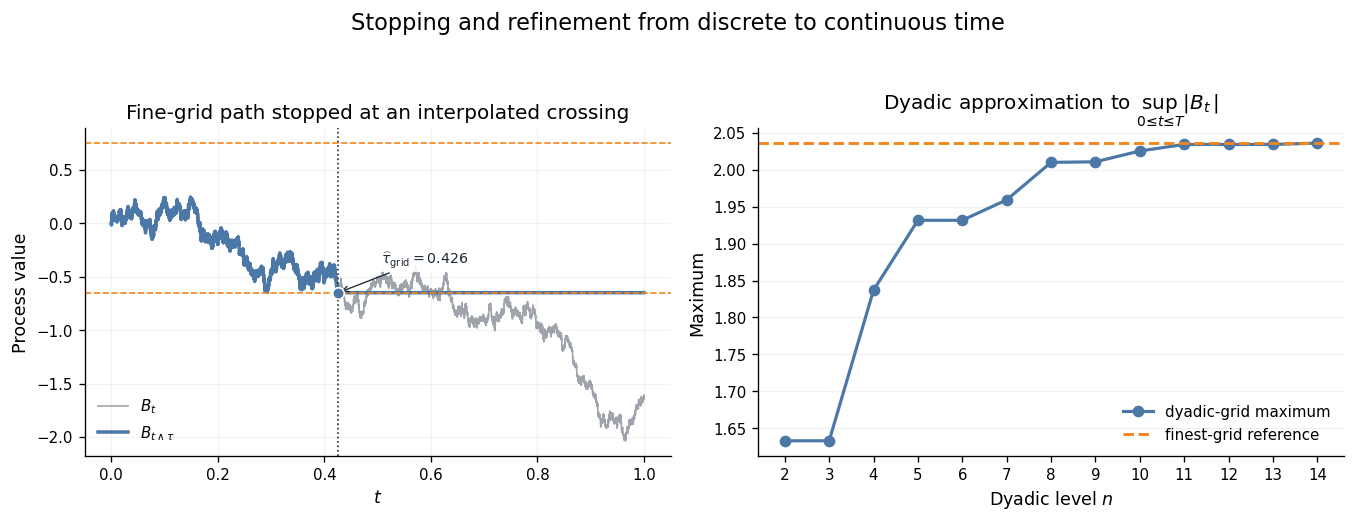

In [5]:
rng = np.random.default_rng(SEED + 4)
T = 1.0
max_level = 14
n_steps = 2**max_level
time = np.linspace(0.0, T, n_steps + 1)
dt = T / n_steps
upper_boundary = 0.75
lower_boundary = -0.65

# Select a reproducible path that reaches one boundary before T.
for _ in range(100):
    increments = np.sqrt(dt) * rng.standard_normal(n_steps)
    path = np.concatenate(([0.0], np.cumsum(increments)))
    hit_indices = np.flatnonzero((path >= upper_boundary) | (path <= lower_boundary))
    if hit_indices.size:
        break
else:
    raise RuntimeError("No boundary hit was found in the reproducible path search.")

hit_index = int(hit_indices[0])
boundary = upper_boundary if path[hit_index] >= upper_boundary else lower_boundary
previous_value = path[hit_index - 1]
crossing_fraction = (boundary - previous_value) / (path[hit_index] - previous_value)
tau = time[hit_index - 1] + crossing_fraction * dt

stopped_time = np.concatenate((time[:hit_index], [tau, T]))
stopped_path = np.concatenate((path[:hit_index], [boundary, boundary]))

# Nested dyadic maxima for the non-negative submartingale |B_t|.
dyadic_levels = np.arange(2, max_level + 1)
dyadic_maxima = []
for level in dyadic_levels:
    spacing = 2 ** (max_level - level)
    grid_indices = np.arange(0, n_steps + 1, spacing)
    dyadic_maxima.append(np.abs(path[grid_indices]).max())
dyadic_maxima = np.asarray(dyadic_maxima)
dense_grid_maximum = np.abs(path).max()

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4))

axes[0].plot(time, path, color=GREY, linewidth=1.0, alpha=0.65, label="$B_t$")
axes[0].plot(stopped_time, stopped_path, color=BLUE, linewidth=2.1, label=r"$B_{t\wedge\tau}$")
axes[0].axhline(upper_boundary, color=ORANGE, linestyle="--", linewidth=1.0)
axes[0].axhline(lower_boundary, color=ORANGE, linestyle="--", linewidth=1.0)
axes[0].axvline(tau, color=INK, linestyle=":", linewidth=1.0)
axes[0].scatter([tau], [boundary], color=BLUE, edgecolor="white", s=48, zorder=4)
axes[0].annotate(
    rf"$\widehat{{\tau}}_{{\mathrm{{grid}}}}={tau:.3f}$",
    xy=(tau, boundary),
    xytext=(tau + 0.08, boundary + 0.28),
    arrowprops={"arrowstyle": "->", "color": INK, "linewidth": 0.8},
    fontsize=8.5,
    color=INK,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.88, "pad": 1.5},
)
axes[0].set_title("Fine-grid path stopped at an interpolated crossing")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("Process value")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(dyadic_levels, dyadic_maxima, color=BLUE, marker="o", linewidth=1.9, label="dyadic-grid maximum")
axes[1].axhline(dense_grid_maximum, color=ORANGE, linestyle="--", linewidth=1.7, label="finest-grid reference")
axes[1].set_xticks(dyadic_levels)
axes[1].set_title(r"Dyadic approximation to $\sup_{0\leq t\leq T}|B_t|$")
axes[1].set_xlabel("Dyadic level $n$")
axes[1].set_ylabel("Maximum")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.17)

fig.suptitle("Stopping and refinement from discrete to continuous time", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> A fine-grid Brownian rendering stopped at its interpolated boundary crossing, with nested dyadic approximations to the continuous-time maximum of $|B_t|$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The left panel linearly interpolates between two adjacent grid values to estimate the continuous hitting time $\tau$; the displayed $\widehat{\tau}_{\mathrm{grid}}$ is therefore a numerical approximation. The stopped rendering follows the sampled path up to this crossing and then remains fixed. On the right, each dyadic grid contains the preceding grid, so its maximum can only increase; the values settle at the finest-grid reference as the mesh becomes dense. This refinement is the visual link between the discrete results in Chapter 2 and their continuous-time versions.</p>

## 5. Hitting times of Brownian motion

For $A,B>0$, define

$$
\tau=\inf\{t\geq0:B_t=-B\ \text{or}\ B_t=A\},\qquad \inf\varnothing=\infty.
$$

Brownian motion reaches one of the two boundaries almost surely, and Chapter 3 gives

$$
\mathbb P(B_\tau=A)=\frac{B}{A+B},\qquad \mathbb E(\tau)=AB.
$$

The simulation below varies the time mesh so that discretisation error can be separated from Monte Carlo uncertainty.

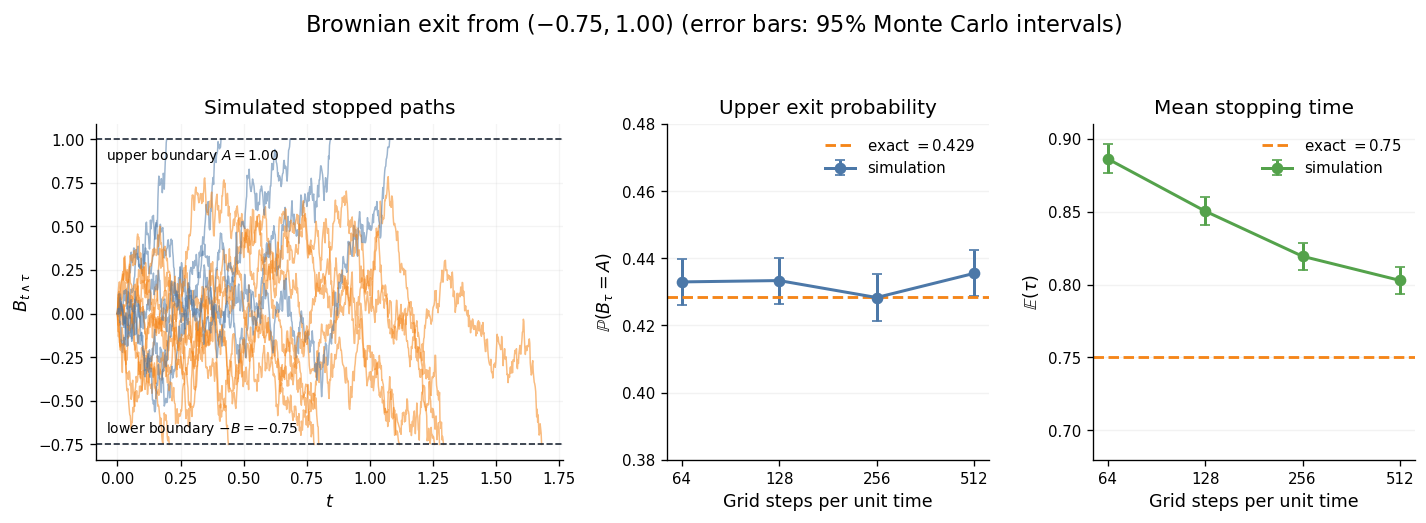

In [6]:
def simulate_brownian_exit(A, B, dt, n_paths, rng, max_time=20.0):
    position = np.zeros(n_paths)
    tau = np.zeros(n_paths)
    upper_exit = np.zeros(n_paths, dtype=bool)
    active = np.ones(n_paths, dtype=bool)
    max_steps = int(np.ceil(max_time / dt))

    for step in range(1, max_steps + 1):
        active_indices = np.flatnonzero(active)
        if active_indices.size == 0:
            break
        position[active_indices] += np.sqrt(dt) * rng.standard_normal(active_indices.size)
        stopped = (position[active_indices] >= A) | (position[active_indices] <= -B)
        stopped_indices = active_indices[stopped]
        if stopped_indices.size:
            tau[stopped_indices] = step * dt
            upper_exit[stopped_indices] = position[stopped_indices] >= A
            active[stopped_indices] = False

    if active.any():
        raise RuntimeError("Some simulated paths did not reach a boundary before max_time.")
    return upper_exit, tau


A = 1.00
B = 0.75
n_paths = 20_000
steps_per_unit = np.array([64, 128, 256, 512])

probability_estimates = []
probability_intervals = []
mean_time_estimates = []
mean_time_intervals = []

for resolution in steps_per_unit:
    upper_exit, tau = simulate_brownian_exit(
        A=A,
        B=B,
        dt=1 / resolution,
        n_paths=n_paths,
        rng=np.random.default_rng(SEED + 500 + int(resolution)),
    )
    probability = upper_exit.mean()
    mean_time = tau.mean()
    probability_estimates.append(probability)
    probability_intervals.append(1.96 * np.sqrt(probability * (1 - probability) / n_paths))
    mean_time_estimates.append(mean_time)
    mean_time_intervals.append(1.96 * tau.std(ddof=1) / np.sqrt(n_paths))

probability_estimates = np.asarray(probability_estimates)
probability_intervals = np.asarray(probability_intervals)
mean_time_estimates = np.asarray(mean_time_estimates)
mean_time_intervals = np.asarray(mean_time_intervals)
exact_probability = B / (A + B)
exact_mean_time = A * B

# Readable paths at the finest displayed mesh.
rng_paths = np.random.default_rng(SEED + 505)
dt_path = 1 / steps_per_unit[-1]
sample_histories = []
for _ in range(14):
    history = [0.0]
    while -B < history[-1] < A:
        history.append(history[-1] + np.sqrt(dt_path) * rng_paths.standard_normal())
    hit_upper = history[-1] >= A
    history[-1] = A if hit_upper else -B
    sample_histories.append(np.asarray(history))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.45, 1, 1]})

for history in sample_histories:
    path_time = np.arange(history.size) * dt_path
    color = BLUE if history[-1] == A else ORANGE
    axes[0].plot(path_time, history, color=color, linewidth=0.9, alpha=0.55)
axes[0].axhline(A, color=INK, linestyle="--", linewidth=1.0)
axes[0].axhline(-B, color=INK, linestyle="--", linewidth=1.0)
axes[0].text(0.02, A - 0.04, rf"upper boundary $A={A:.2f}$", transform=axes[0].get_yaxis_transform(), va="top", fontsize=8.3)
axes[0].text(0.02, -B + 0.04, rf"lower boundary $-B={-B:.2f}$", transform=axes[0].get_yaxis_transform(), va="bottom", fontsize=8.3)
axes[0].set_title("Simulated stopped paths")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$B_{t\wedge\tau}$")
axes[0].grid(alpha=0.13)

x_positions = np.arange(steps_per_unit.size)
axes[1].errorbar(
    x_positions,
    probability_estimates,
    yerr=probability_intervals,
    color=BLUE,
    marker="o",
    linewidth=1.8,
    capsize=3,
    label="simulation",
)
axes[1].axhline(exact_probability, color=ORANGE, linestyle="--", linewidth=1.7, label=rf"exact $={exact_probability:.3f}$")
axes[1].set_xticks(x_positions, labels=steps_per_unit)
axes[1].set_ylim(0.38, 0.48)
axes[1].set_title("Upper exit probability")
axes[1].set_xlabel("Grid steps per unit time")
axes[1].set_ylabel(r"$\mathbb{P}(B_\tau=A)$")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.16)

axes[2].errorbar(
    x_positions,
    mean_time_estimates,
    yerr=mean_time_intervals,
    color=GREEN,
    marker="o",
    linewidth=1.8,
    capsize=3,
    label="simulation",
)
axes[2].axhline(exact_mean_time, color=ORANGE, linestyle="--", linewidth=1.7, label=rf"exact $={exact_mean_time:.2f}$")
axes[2].set_xticks(x_positions, labels=steps_per_unit)
axes[2].set_ylim(0.68, 0.91)
axes[2].set_title("Mean stopping time")
axes[2].set_xlabel("Grid steps per unit time")
axes[2].set_ylabel(r"$\mathbb{E}(\tau)$")
axes[2].legend(frameon=False)
axes[2].grid(axis="y", alpha=0.16)

fig.suptitle(
    rf"Brownian exit from $(-{B:.2f},{A:.2f})$ (error bars: 95% Monte Carlo intervals)",
    fontsize=13.5,
)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> Brownian paths stopped at $-B$ or $A$, with simulated exit probabilities and mean stopping times across four time meshes.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The path panel is the continuous-time counterpart of gambler's ruin. As the grid is refined, the exit-probability estimates remain close to $B/(A+B)=0.429$, while the mean stopping time moves toward $AB=0.75$. The error bars measure Monte Carlo uncertainty at each mesh, and the remaining movement across meshes reflects time-discretisation error.</p>

## 6. Hölder regularity and nowhere differentiability

For $0<\alpha<1$, a path is Hölder-$\alpha$ when its increments can be bounded by $C|t-s|^\alpha$. Chapter 3 shows that Brownian paths are almost surely Hölder-$\alpha$ for every $\alpha<1/2$, but not locally Hölder-$\alpha$ for $\alpha>1/2$. Consequently, they are almost surely nowhere differentiable. The comparison below uses $\alpha=0.4$ and $\alpha=0.6$, one value on each side of the threshold $1/2$.

The same simulated path is used in all four panels. For a window of width $h$, the zoom panel stretches local time back to $[0,1]$ and divides the vertical increment by $\sqrt h$. The lower-left panel uses

$$
R_\alpha(h)=\frac{\max_t|B_{t+h}-B_t|}{h^\alpha},
$$

which is the size of the Hölder constant required at the displayed scale $h$.


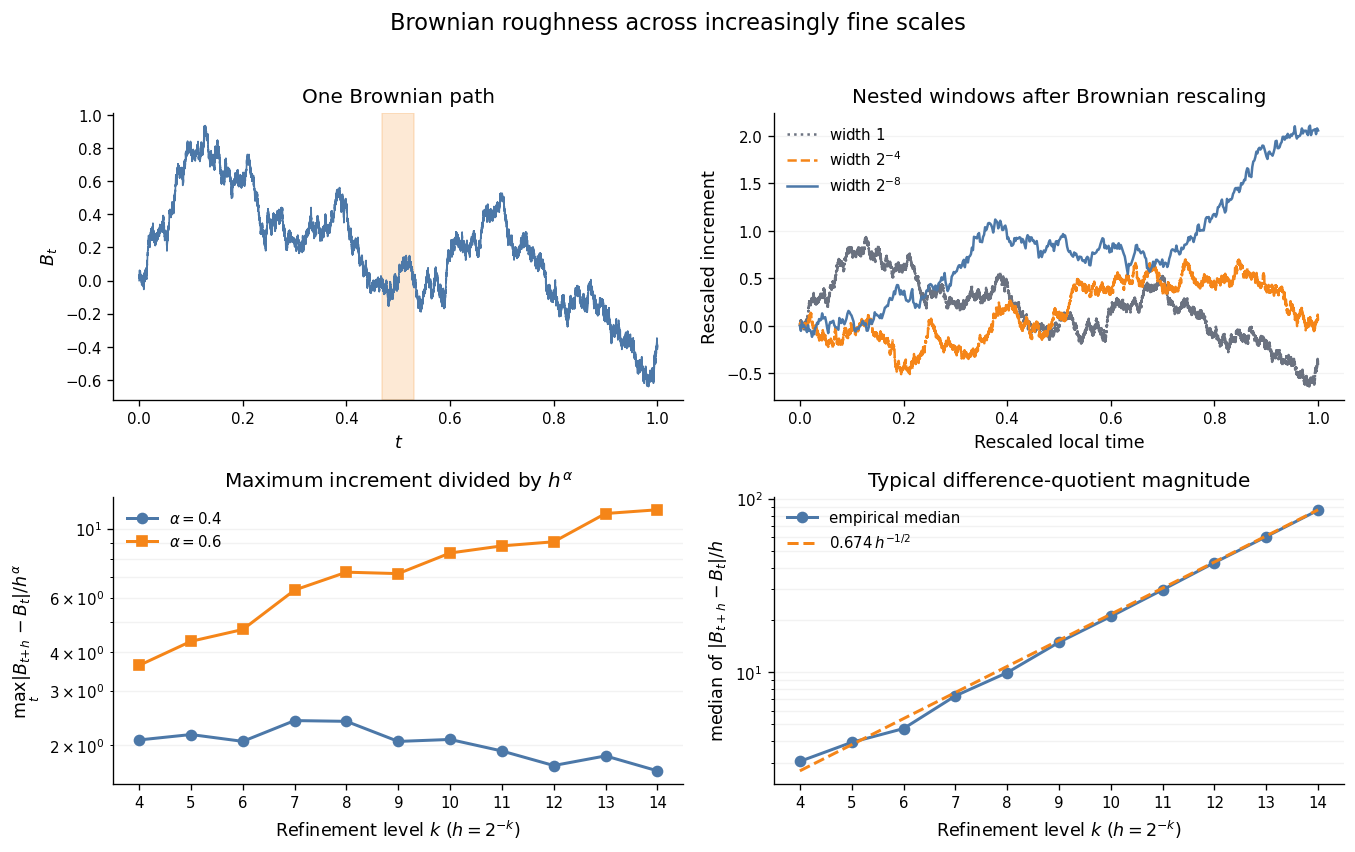

In [7]:
rng = np.random.default_rng(SEED + 6)
T = 1.0
max_level = 17
n_steps = 2**max_level
time, rough_paths, _ = simulate_brownian_paths(n_paths=1, n_steps=n_steps, T=T, rng=rng)
path = rough_paths[0]

# Nested windows, rescaled by the Brownian square-root rule.
centre = 0.5
window_widths = [1.0, 1 / 16, 1 / 256]
zoom_curves = []
for width in window_widths:
    left = centre - width / 2
    right = centre + width / 2
    mask = (time >= left) & (time <= right)
    local_time = (time[mask] - left) / width
    local_path = (path[mask] - path[mask][0]) / np.sqrt(width)
    zoom_curves.append((local_time, local_path))

# Uniform increment ratios on dyadic scales.
refinement_levels = np.arange(4, 15)
mesh_sizes = 2.0 ** (-refinement_levels)
maximum_increments = []
median_difference_quotients = []
for level in refinement_levels:
    lag = 2 ** (max_level - level)
    increments = np.abs(path[lag:] - path[:-lag])
    h = lag / n_steps
    maximum_increments.append(increments.max())
    median_difference_quotients.append(np.median(increments / h))

maximum_increments = np.asarray(maximum_increments)
median_difference_quotients = np.asarray(median_difference_quotients)
holder_ratio_04 = maximum_increments / mesh_sizes**0.4
holder_ratio_06 = maximum_increments / mesh_sizes**0.6
typical_slope_reference = 0.67449 / np.sqrt(mesh_sizes)

fig, axes = plt.subplots(2, 2, figsize=(11.4, 7.2))

axes[0, 0].plot(time, path, color=BLUE, linewidth=1.0)
axes[0, 0].axvspan(centre - window_widths[1] / 2, centre + window_widths[1] / 2, color=ORANGE, alpha=0.18)
axes[0, 0].set_title("One Brownian path")
axes[0, 0].set_xlabel("$t$")
axes[0, 0].set_ylabel("$B_t$")

zoom_styles = [
    (GREY, ":", "width $1$"),
    (ORANGE, "--", "width $2^{-4}$"),
    (BLUE, "-", "width $2^{-8}$"),
]
for (local_time, local_path), (color, linestyle, label) in zip(zoom_curves, zoom_styles):
    axes[0, 1].plot(local_time, local_path, color=color, linestyle=linestyle, linewidth=1.5, label=label)
axes[0, 1].set_title("Nested windows after Brownian rescaling")
axes[0, 1].set_xlabel("Rescaled local time")
axes[0, 1].set_ylabel("Rescaled increment")
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(axis="y", alpha=0.14)

axes[1, 0].plot(refinement_levels, holder_ratio_04, color=BLUE, marker="o", linewidth=1.8, label=r"$\alpha=0.4$")
axes[1, 0].plot(refinement_levels, holder_ratio_06, color=ORANGE, marker="s", linewidth=1.8, label=r"$\alpha=0.6$")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xticks(refinement_levels)
axes[1, 0].set_title(r"Maximum increment divided by $h^\alpha$")
axes[1, 0].set_xlabel(r"Refinement level $k$ ($h=2^{-k}$)")
axes[1, 0].set_ylabel(r"$\max_t|B_{t+h}-B_t|/h^\alpha$")
axes[1, 0].legend(frameon=False)
axes[1, 0].grid(axis="y", which="both", alpha=0.16)

axes[1, 1].plot(
    refinement_levels,
    median_difference_quotients,
    color=BLUE,
    marker="o",
    linewidth=1.8,
    label="empirical median",
)
axes[1, 1].plot(
    refinement_levels,
    typical_slope_reference,
    color=ORANGE,
    linestyle="--",
    linewidth=1.8,
    label=r"$0.674\,h^{-1/2}$",
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xticks(refinement_levels)
axes[1, 1].set_title("Typical difference-quotient magnitude")
axes[1, 1].set_xlabel(r"Refinement level $k$ ($h=2^{-k}$)")
axes[1, 1].set_ylabel(r"median of $|B_{t+h}-B_t|/h$")
axes[1, 1].legend(frameon=False)
axes[1, 1].grid(axis="y", which="both", alpha=0.16)

fig.suptitle("Brownian roughness across increasingly fine scales", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


<p class="figure-caption"><strong>Figure 6.</strong> Nested Brownian zooms, Hölder-scaled maximum increments, and difference quotients across dyadic refinements.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Read the panels clockwise from the upper left. The orange band marks the region around $t=0.5$ that is magnified next. In the upper-right panel, the grey, orange, and blue curves use nested windows of widths $1$, $2^{-4}$, and $2^{-8}$. Rescaling time to the same horizontal interval and vertical changes by $\sqrt h$ preserves a visibly jagged shape at every scale. In the lower-left panel, $R_\alpha(h)$ is the Hölder bound required at scale $h$: the $\alpha=0.4$ values stay near $2$, whereas the $\alpha=0.6$ values rise from roughly $4$ to above $10$ as $h$ shrinks. In the lower-right panel, the typical absolute difference quotient rises from about $3$ to nearly $90$ along the $h^{-1/2}$ reference, illustrating divergence as $h$ decreases. The common $\sqrt h$ increment scale connects the threshold at $\alpha=1/2$ with nowhere differentiability. Theorem 3.22 and Corollary 3.23 supply the almost-sure regularity conclusions; these finite-grid panels display the corresponding scale pattern.</p>